In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
import numpy as np

In [2]:
df=pd.read_csv("../Datasets/insurance.csv")
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


In [3]:
df.shape

(1338, 7)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [6]:
px.histogram(df,x="age",color="smoker")

In [7]:
px.histogram(df,x="bmi",color="smoker")

In [8]:
px.histogram(df,x="children")

In [9]:
px.box(df,x="children",y="expenses",color="smoker")

In [10]:
px.box(df,x="region",y="expenses")

<Axes: xlabel='sex', ylabel='count'>

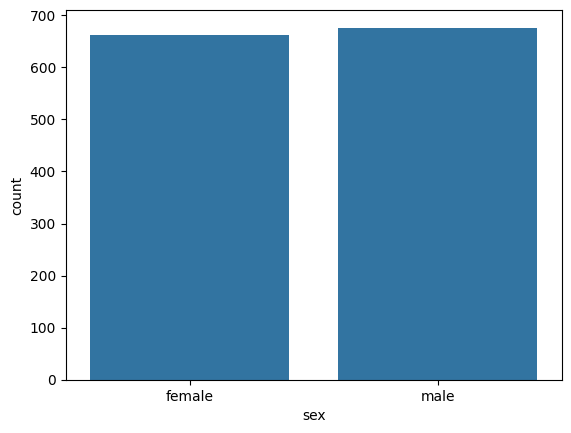

In [11]:
sns.countplot(x="sex",data=df)

In [12]:
df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(1)

In [14]:
df.drop_duplicates(inplace=True)

In [15]:
df.shape

(1337, 7)

<Axes: >

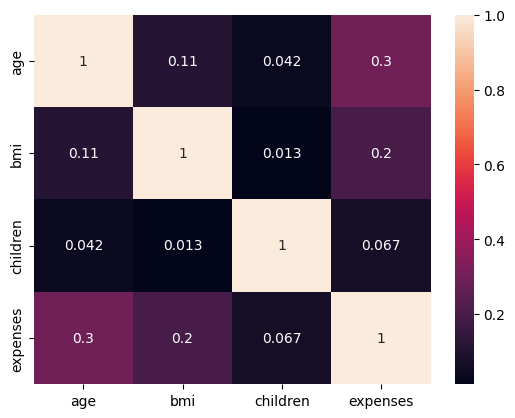

In [16]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [17]:
x=df[["age"]]
y=df["expenses"]


In [18]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [19]:
print("x_train shape:",x_train.shape)
print("x_test shape:",x_test.shape)
print("y_train shape:",y_train.shape)
print("y_test shape:",y_test.shape)

x_train shape: (1069, 1)
x_test shape: (268, 1)
y_train shape: (1069,)
y_test shape: (268,)


In [20]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
print("m",model.coef_)
print("c",model.intercept_)


m [242.25815214]
c 3534.0918717024415


In [21]:
def rmse(y_true,y_pred):
    return np.sqrt(np.mean((y_true-y_pred)**2))

In [22]:
y_pred=model.predict(x_test)
rmse(y_test,y_pred)

np.float64(12894.780080873967)

In [23]:
y_pred

array([15404.74132659, 10559.57828378, 15889.25763088, 11044.09458806,
       11044.09458806, 15404.74132659,  9106.02937094,  8863.7712188 ,
       13951.19241375, 15404.74132659, 18311.83915228, 16131.51578302,
       11286.3527402 , 18311.83915228, 12013.12719663, 14435.70871803,
        8379.25491452, 12255.38534877,  9832.80382736, 10559.57828378,
        8379.25491452, 12255.38534877, 15404.74132659, 12982.15980519,
       11528.61089234,  8621.51306666, 13708.93426161, 18069.58100014,
       15404.74132659, 15162.48317445, 11044.09458806, 15646.99947874,
        7894.73861023, 17827.322848  , 16616.0320873 , 15889.25763088,
        8136.99676237, 10801.83643592, 16373.77393516, 14677.96687017,
        8863.7712188 , 13951.19241375, 13951.19241375, 15889.25763088,
       14677.96687017, 10317.32013164,  7894.73861023, 13951.19241375,
       10317.32013164, 12982.15980519, 10317.32013164, 12982.15980519,
       13951.19241375,  8379.25491452, 13708.93426161, 14193.45056589,
      

In [24]:
px.scatter(x=x_test["age"],y=[y_test,y_pred])

In [25]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print("R2 score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))

R2 score: 0.09513000201438315
MAE: 9657.789547996737
MSE: 166275353.33410403


In [26]:
x=df.drop("expenses",axis=1)
x=pd.get_dummies(x,drop_first=True)
y=df["expenses"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


In [27]:
x_train

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
1114,23,24.5,0,True,False,False,False,False
968,21,25.7,2,True,False,False,False,False
599,52,37.5,2,False,False,True,False,False
170,63,41.5,0,True,False,False,True,False
275,47,26.6,2,False,False,False,False,False
...,...,...,...,...,...,...,...,...
1096,51,35.0,2,False,True,False,False,False
1131,27,45.9,2,True,False,False,False,True
1295,20,22.0,1,True,False,False,False,True
861,38,28.0,3,False,False,False,False,True


In [28]:
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("R2 score:",r2_score(y_test,y_pred))
print("MAE:",mean_absolute_error(y_test,y_pred))
print("MSE:",mean_squared_error(y_test,y_pred))

R2 score: 0.8069099329048419
MAE: 4177.267596014916
MSE: 35481471.59594919


In [34]:
checkvalue=np.array([[20,28,5,False,True,True,False,False]])
model.predict(checkvalue)

c:\Users\BHAVYA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([28146.47715208])

In [35]:
fish_df=pd.read_csv("../Datasets/Fish.csv")
fish_df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [39]:
x=fish_df.drop(["Species","Weight"],axis=1)
y=fish_df["Weight"]
x_train1,x_test1,y_train1,y_test1=train_test_split(x,y,test_size=0.05,random_state=42)
x_train2,x_test2,y_train2,y_test2=train_test_split(x,y,test_size=0.1,random_state=42)
x_train3,x_test3,y_train3,y_test3=train_test_split(x,y,test_size=0.15,random_state=42)
x_train4,x_test4,y_train4,y_test4=train_test_split(x,y,test_size=0.20,random_state=42)
x_train5,x_test5,y_train5,y_test5=train_test_split(x,y,test_size=0.25,random_state=42)

In [44]:
def evaluate_model(x_train,y_train,x_test,y_test):
    model.fit(x_train,y_train)
    y_pred=model.predict(x_test)
    return r2_score(y_test,y_pred)


In [45]:
print("train test split 1",evaluate_model(x_train1,y_train1,x_test1,y_test1))
print("train test split 2",evaluate_model(x_train2,y_train2,x_test2,y_test2))
print("train test split 3",evaluate_model(x_train3,y_train3,x_test3,y_test3))
print("train test split 4",evaluate_model(x_train4,y_train4,x_test4,y_test4))
print("train test split 5",evaluate_model(x_train5,y_train5,x_test5,y_test5))

train test split 1 0.7714604379571599
train test split 2 0.8979646365192799
train test split 3 0.8980209372627835
train test split 4 0.8821430593048696
train test split 5 0.8828776020785211


In [48]:
r2_1=evaluate_model(x_train1,y_train1,x_test1,y_test1)
r2_2=evaluate_model(x_train2,y_train2,x_test2,y_test2)
r2_3=evaluate_model(x_train3,y_train3,x_test3,y_test3)
r2_4=evaluate_model(x_train4,y_train4,x_test4,y_test4)
r2_5=evaluate_model(x_train5,y_train5,x_test5,y_test5)

In [49]:
px.line(x=[0.05,0.1,0.15,0.2,0.25],y=[r2_1,r2_2,r2_3,r2_4,r2_5],markers=True)

In [ ]:
model.fit(x_train2,y_train2)
model.predict([[20,20,20,5,10]])


c:\Users\BHAVYA\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([425.62436223])